In [ ]:
!pip install pydub librosa ffmpeg

In [ ]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
from pydub import AudioSegment
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks')

import taxonomia


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def obtener_paths_cantos(base_dir):
    data = []

    # Recorrer las familias
    for familia in os.listdir(base_dir):
        familia_path = os.path.join(base_dir, familia)
        if os.path.isdir(familia_path):
            # Recorrer los géneros
            for genero in os.listdir(familia_path):
                genero_path = os.path.join(familia_path, genero)
                if os.path.isdir(genero_path):
                    # Recorrer las especies
                    for especie in os.listdir(genero_path):
                        especie_path = os.path.join(genero_path, especie)
                        if os.path.isdir(especie_path):
                            # Recorrer los nombres comunes
                            for nombre_comun in os.listdir(especie_path):
                                nombre_comun_path = os.path.join(especie_path, nombre_comun)
                                if os.path.isdir(nombre_comun_path):
                                    # Recorrer los cantos
                                    for canto in os.listdir(nombre_comun_path):
                                        canto_path = os.path.join(nombre_comun_path, canto)
                                        if os.path.isfile(canto_path):
                                            # Añadir la información al DataFrame
                                            data.append({
                                                'Specie': especie,
                                                'Genus': genero,
                                                'Family': familia,
                                                'audio_path': canto_path
                                            })

    # Crear el DataFrame
    df = pd.DataFrame(data)
    return df

In [ ]:
# Definir la ruta base
base_dir = '/content/drive/My Drive/songs'

# Obtener el DataFrame
df = obtener_paths_cantos(base_dir)
print(df.shape)
df = df.sort_values(by=['Specie'], ascending=False)

# Mostrar las primeras 4 filas
df.head(4)

(40276, 4)


,Specie,Genus,Family,audio_path
38446,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/content/drive/My Drive/songs/Passerellidae/Zo...
38458,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/content/drive/My Drive/songs/Passerellidae/Zo...
38466,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/content/drive/My Drive/songs/Passerellidae/Zo...
38465,Zonotrichia leucophrys,Zonotrichia,Passerellidae,/content/drive/My Drive/songs/Passerellidae/Zo...


In [ ]:
lista_familias = df['Family'].unique().tolist()
lista_familias.sort()
lista_familias

['Alaudidae',
 'Bombycillidae',
 'Capitonidae',
 'Cinclidae',
 'Conopophagidae',
 'Corvidae',
 'Cotingidae',
 'Donacobiidae',
 'Estrildidae',
 'Falconidae',
 'Formicariidae',
 'Fringillidae',
 'Furnariidae',
 'Grallaridae',
 'Hirundinidae',
 'Icteridae',
 'Melanopareiidae',
 'Mimidae',
 'Mitrospingidae',
 'Motacillidae',
 'Onychorhynchidae',
 'Passerellidae',
 'Passeridae',
 'Picidae',
 'Pipridae',
 'Ploceidae',
 'Polioptilidae',
 'Psittacidae',
 'Rhamphastidae',
 'Rhinocryptidae',
 'Rhodinocichlidae',
 'Sapayoidae',
 'Thamnophilidae',
 'Thraupidae',
 'Tityridae',
 'Troglodytidae',
 'Turdidae',
 'Tyrannidae',
 'Vireonidae']

In [ ]:
familias_procesadas = ['Alaudidae','Bombycillidae','Capitonidae','Cinclidae','Conopophagidae','Corvidae','Cotingidae','Donacobiidae','Estrildidae','Falconidae', 'Formicariidae',
                       'Fringillidae', 'Fringillidae', 'Furnariidae', 'Grallaridae', 'Hirundinidae', 'Icteridae', 'Melanopareiidae', 'Mimidae', 'Mitrospingidae', 'Motacillidae',
                       'Onychorhynchidae', 'Passerellidae', 'Passeridae', 'Picidae', 'Pipridae', 'Ploceidae', 'Polioptilidae', 'Psittacidae', 'Rhamphastidae', 'Rhinocryptidae',
                       'Rhodinocichlidae', 'Sapayoidae', 'Thamnophilidae', 'Thraupidae', 'Tityridae', 'Troglodytidae', 'Turdidae']

lista_familias = [familia for familia in lista_familias if familia not in familias_procesadas]
lista_familias

['Tyrannidae', 'Vireonidae']

In [ ]:
def load_audio(path):
    # Carga el archivo de audio
    try:
        audio = AudioSegment.from_file(path, "mp3")
        return True  # Indicar que la carga fue exitosa
    except Exception as e:
        print(f"Error al cargar el archivo de audio - Eliminando archivo: {path}: {e}")
        os.remove(path)  # Eliminar el archivo inválido
        return False  # Indicar que la carga falló

def validate_audio(df, lista_familias):
    for familia in lista_familias:
        # Filtrar el DataFrame para esta familia
        subset_df = df[df['Family'] == familia]

        print(f"Procesando la familia: {familia} - {len(subset_df)} archivos encontrados")

        # Iterar a través del DataFrame filtrado
        for index, row in subset_df.iterrows():
            path = row['audio_path']
            print(f"Ind. {index} - Validando archivo: {path} para la familia: {familia}")
            success = load_audio(path)
            if not success:
                print(f"Ind. {index} - Archivo inválido eliminado: {path}")
            else:
                print(f"Ind. {index} - Archivo cargado exitosamente: {path}")

#validate_audio(df, lista_familias)

In [ ]:
# seleccionar aleatoriamente 100 filas para las especies que superan las 100 muestras
df_sample = df.groupby('Specie').apply(lambda x: x.sample(100, random_state=42) if len(x) > 100 else x).reset_index(drop=True)

# elimina las especies con menos de 15 muestras
df_sample = df_sample.groupby('Specie').filter(lambda x: len(x) >= 15)

<ipython-input-8-32ee8fd55af0>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('Specie').apply(lambda x: x.sample(100, random_state=42) if len(x) > 100 else x).reset_index(drop=True)


In [ ]:
print(df_sample.shape)
df_sample.head(4)

(31373, 4)


,Specie,Genus,Family,audio_path
0,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...
1,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...
2,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...
3,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...


In [ ]:
df_sample['Specie'].nunique()

667

In [ ]:
familia = taxonomia.capitalize_family_genus(taxonomia.genus_family)
df_sample['Family'] = df_sample['Genus'].map(familia)
df_sample['Suborder'] = df_sample['Family'].map(taxonomia.suborder)

In [ ]:
print(df_sample.shape)
df_sample.head()

(31373, 5)


,Specie,Genus,Family,audio_path,Suborder
0,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...,tiranni
1,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...,tiranni
2,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...,tiranni
3,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...,tiranni
4,Grallaria guatimalensis,Grallaria,Grallaridae,/content/drive/My Drive/songs/Grallaridae/Gral...,tiranni


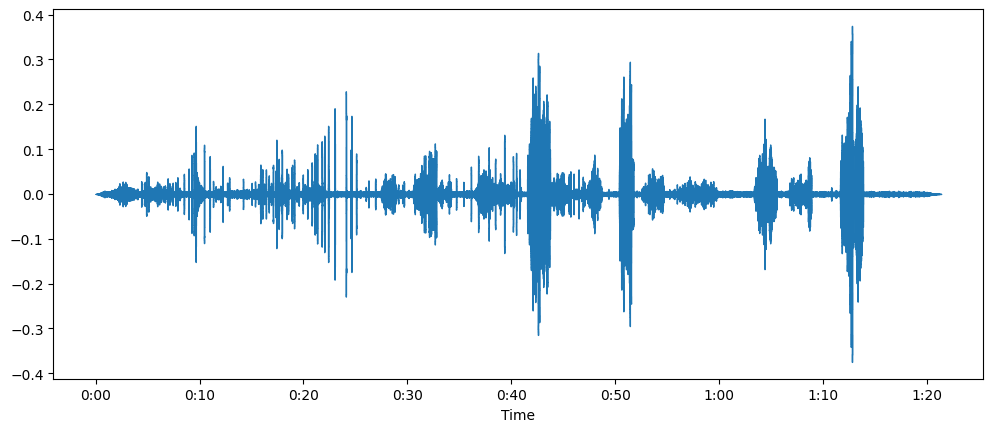

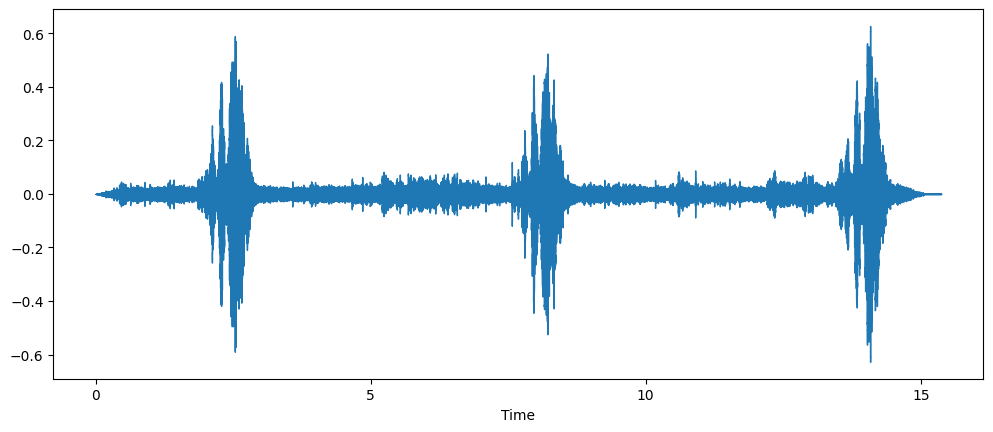

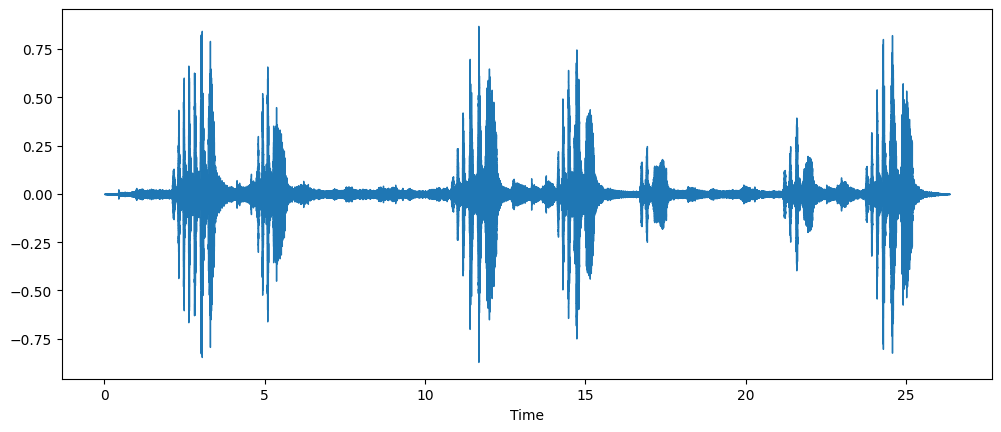

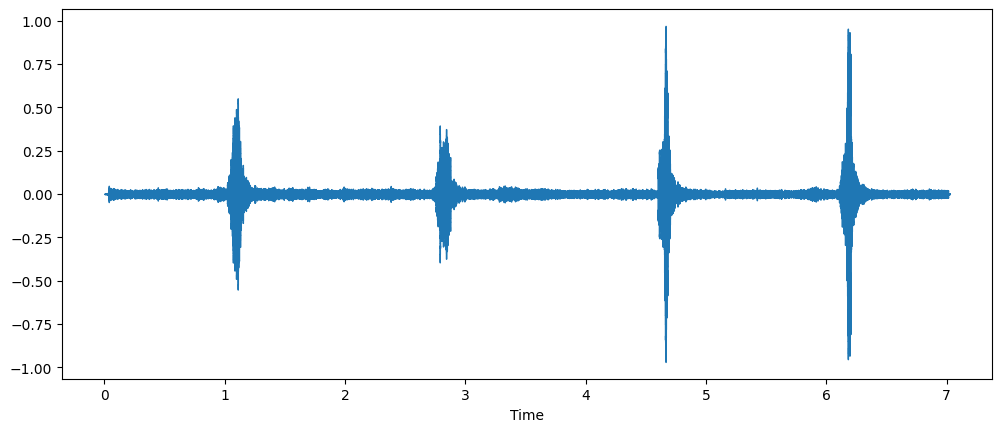

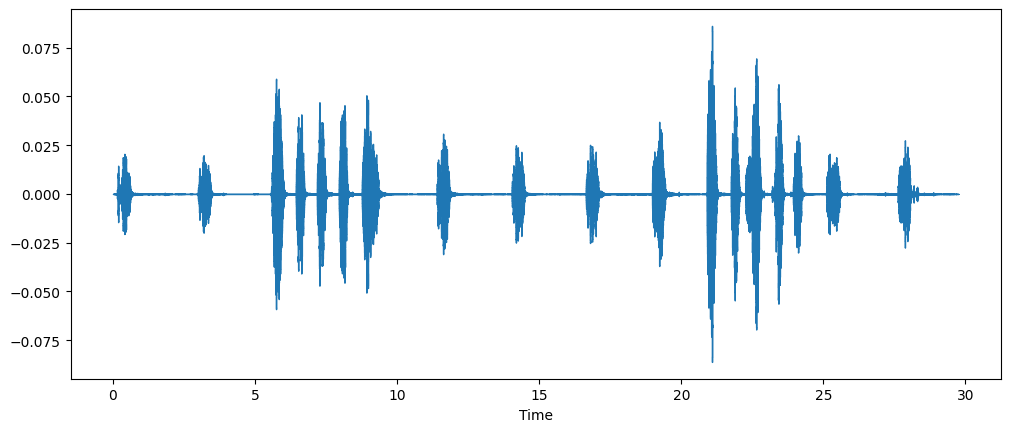

In [ ]:
audio_segments = []

for i in range(5):
    path = df_sample.sample(1)['audio_path'].values[0]
    y, sr = librosa.load(path, sr=None, mono=True)
    plt.figure().set_figwidth(12)
    librosa.display.waveshow(y, sr=sr)
    plt.show()

    # Guardar el archivo de audio en un objeto diferente
    audio = AudioSegment.from_file(path, "mp3")
    audio_segments.append(audio)

In [ ]:
audio_segments[0]

In [ ]:
audio_segments[1]

In [ ]:
audio_segments[2]

In [ ]:
audio_segments[3]

In [ ]:
audio_segments[4]

In [ ]:
# df_sample = df_sample[df_sample['Family']=='Troglodytidae']
# df_sample.shape

In [ ]:
df_sample = df_sample.rename(columns={'Specie':'label', 'Path': 'audio_path'})
df_sample = df_sample.reset_index(drop=True)
df_sample.shape

(31373, 5)

In [ ]:
# # guardar el dataframe en un archivo csv
df_sample.to_csv('/content/drive/My Drive/data_passerifromes/paths_cantos_passeriformes.csv', index=False)

In [ ]:
# split de los datos en train y test para el modelo
from sklearn.model_selection import train_test_split
X_train_muestra, X_test_muestra = train_test_split(
    df_sample,
    test_size=0.5,
    random_state=42,
    stratify=df_sample['label']
    )

# split de validacion
X_val_muestra, X_test_muestra = train_test_split(
    X_test_muestra,
    test_size=0.5,
    random_state=42,
    stratify=X_test_muestra['label']
    )

In [ ]:
# labels unicos en los datos
print(X_train_muestra['label'].nunique())
print(X_test_muestra['label'].nunique())
print(X_val_muestra['label'].nunique())

667
667
667


In [ ]:
# dimensiones de los datos
print(X_train_muestra.shape)
print(X_val_muestra.shape)
print(X_test_muestra.shape)

(15686, 5)
(7843, 5)
(7844, 5)


In [ ]:
X_val_muestra.to_csv('/content/drive/My Drive/data_passerifromes/val_muestra.csv', index=False)
X_train_muestra.to_csv('/content/drive/My Drive/data_passerifromes/train_muestra.csv', index=False)
X_test_muestra.to_csv('/content/drive/My Drive/data_passerifromes/test_muestra.csv', index=False)